# Praktikum 4 — Probability and Statistical Inference

**Data Science · Magister Ilmu Komputer, FMIPA UGM**
Companion to **Chapter 4**. Assignment weight: **3%**.

---

## What you will do

This notebook follows the nine sections of chapter 4 in order, so a slide and
a cell should always be findable from one another.

| § | Chapter 4 | What you do here |
| --- | --- | --- |
| 0 | Motivating example | Meet the two checkout pages, and refuse to answer yet |
| 1 | Probability, conditional probability, Bayes | Check the four rules on real counts; feel the base rate |
| 2 | Choosing a distribution | Recover seven distributions from the columns they generated |
| 3 | From a sample to the population | Watch the LLN and CLT converge — and measure where they fail |
| 4 | Confidence intervals | Build them four ways, then *measure* whether they work |
| 5 | Hypothesis testing | Five steps, the null p-value, power, effect size |
| 6 | Multiple testing | Slice the data ten ways, then correct honestly |
| 7 | A/B testing | The full analysis, from sample-ratio check to a shipping decision |
| 8 | Peeking | Simulate the cost of stopping early |
| 9 | Summary | Eight points, then the assessed take-home |

**The dataset.** `data/ab_test.csv` — 70,000 sessions from a two-week
experiment on a checkout page. Every section uses it, so by §9 you will know
it well.

**Run time.** Roughly three minutes end to end; §6 and §8 are the slow parts.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "checks.py").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import checks
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

DATA = ROOT / "data"
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True,
                     "grid.alpha": 0.3, "axes.titleweight": "bold"})

BLUE, RED, GOLD, GREY = "#2E6F9E", "#9C3535", "#C8922A", "#8A8A8A"

# Each simulation section seeds its own generator, so a cell gives the same
# answer no matter what you ran before it. Re-running one section can never
# silently change another section's numbers.

## 0. The question this chapter has to answer  (DEMO)

A checkout page has two versions. Here are the only two numbers most people
ever see.

In [ ]:
ab = pd.read_csv(DATA / "ab_test.csv")
print(f"{len(ab):,} sessions, {ab.shape[1]} columns\n")
print(ab.dtypes.to_string())

headline = ab.groupby("variant")["converted"].mean()
print(f"\nVersion A converts at {headline['A']:.2%}")
print(f"Version B converts at {headline['B']:.2%}")
print(f"\nB is {headline['B'] / headline['A'] - 1:+.1%} better. Ship it?")

**No — that question cannot be answered from those two numbers.** Whether the
gap is real depends on how many sessions produced it, how far such a gap
wanders by chance alone, and what it costs to be wrong.

Write down now, before reading on, the *minimum* extra information you would
need. We come back to your list in §9.

## 1. Probability and conditional probability  (DEMO + TASK)

### 1.1 The four rules, on counts you can check by hand

The rules are usually taught on coins. They are easier to believe on data,
because every probability below is a count divided by 70,000 and you can
verify each one yourself.

In [ ]:
n_all = len(ab)
is_mobile = ab["device"].eq("mobile")
is_conv = ab["converted"].eq(1)

p_m, p_c = is_mobile.mean(), is_conv.mean()
p_both = (is_mobile & is_conv).mean()
p_either = (is_mobile | is_conv).mean()

print(f"{'event':<24}{'count':>9}{'probability':>14}")
print("-" * 47)
for label, mask in [("mobile", is_mobile), ("converted", is_conv),
                    ("mobile AND converted", is_mobile & is_conv),
                    ("mobile OR converted", is_mobile | is_conv)]:
    print(f"{label:<24}{mask.sum():>9,}{mask.mean():>14.4f}")

print(f"\nRule 1  every probability lies in [0, 1]      "
      f"{all(0 <= v <= 1 for v in (p_m, p_c, p_both, p_either))}")
print(f"Rule 2  mobile + desktop = 1                  "
      f"{p_m:.4f} + {1 - p_m:.4f} = {p_m + (1 - p_m):.4f}")
print(f"Rule 3  exclusive events add directly         "
      f"P(mobile or desktop) = {p_m + (1 - p_m):.4f}")
print(f"Rule 4  naive sum P(mobile) + P(converted)  = {p_m + p_c:.4f}   <- too big")
print(f"        minus the double-counted overlap    = {p_m + p_c - p_both:.4f}")
print(f"        observed P(mobile OR converted)     = {p_either:.4f}   <- matches")

Rule 4 is the one people forget, and forgetting it always **overestimates**.
Adding the two events naively claims 72.97% of sessions were mobile-or-
converted; the true figure is 70.25%. The 1,903 sessions that were *both* had
been counted twice.

Rule 3 is only the special case of rule 4 in which the overlap is empty. A
session cannot be mobile *and* desktop, so those two add directly; it can be
mobile *and* converted, so those two cannot.

### 1.2 Conditional probability runs in two directions

In [ ]:
p_c_given_m = is_conv[is_mobile].mean()
p_m_given_c = is_mobile[is_conv].mean()

print(f"P(converted | mobile) = {p_both:.5f} / {p_m:.5f} = {p_c_given_m:.4f}"
      f"  ({p_c_given_m:.2%})")
print(f"P(mobile | converted) = {p_both:.5f} / {p_c:.5f} = {p_m_given_c:.4f}"
      f"  ({p_m_given_c:.2%})")
print(f"\nSame numerator, different denominator -- they differ "
      f"{p_m_given_c / p_c_given_m:.1f}-fold.")

print("\nAre device and conversion independent?")
print(f"  if they were, P(mobile AND converted) = {p_m:.4f} x {p_c:.4f} "
      f"= {p_m * p_c:.5f}")
print(f"  observed                              = {p_both:.5f}")
print("  -> not independent: mobile sessions convert *less* often than average")

**This is the prosecutor's fallacy, in two lines of pandas.** *"Most
conversions come from mobile"* (58%) and *"mobile users rarely convert"*
(4.0%) are both true statements about the same 1,903 sessions. They sound
contradictory only if you drop the conditioning.

Most conversions are mobile because *most sessions* are mobile — 68% of them.
Reversing the two directions is the most common probability error in
analytics, in medicine and in court.

### TASK 4.1

Report $P(\text{mobile} \mid \text{converted})$ as a proportion.

In [ ]:
p_mobile_given_conv = None

checks.task("4.1", p_mobile_given_conv)

### 1.3 Bayes' theorem and the base rate

A fraud detector catches 92% of frauds and has a false-positive rate of 1.5%.
Fraud occurs in 0.3% of transactions. A transaction is flagged. What is the
probability it is genuinely fraudulent?

$$P(F \mid +) = \frac{P(+ \mid F)\,P(F)}{P(+ \mid F)P(F) + P(+ \mid F^c)P(F^c)}$$

In [ ]:
sens, fpr, prev = 0.92, 0.015, 0.003

p_pos = sens * prev + fpr * (1 - prev)
p_fraud_given_pos = sens * prev / p_pos

print(f"P(+)      = {p_pos:.6f}")
print(f"P(F | +)  = {p_fraud_given_pos:.4f}")

# Natural frequencies make the same result intuitive.
N = 100_000
print(f"\nOf {N:,} transactions:")
print(f"  {N*prev:>8,.0f} are fraudulent, of which {N*prev*sens:>7,.0f} are flagged")
print(f"  {N*(1-prev):>8,.0f} are legitimate, of which {N*(1-prev)*fpr:>7,.0f} are flagged")
print(f"  {N*p_pos:>8,.0f} flags in total, of which only "
      f"{N*prev*sens/(N*p_pos):.1%} are genuine")

The false positives dominate because the legitimate group is 332 times larger.
This is not a defect of the detector — it is arithmetic, and it is the reason
accuracy is meaningless on imbalanced data.

### 1.4 Which knob actually fixes it?

The instinct is to make the detector *better at catching fraud*. Measure that
instinct against the alternative before trusting it.

In [ ]:
def posterior(sensitivity, false_pos_rate, prevalence):
    """P(fraud | flagged) from the three design numbers."""
    tp = sensitivity * prevalence
    return tp / (tp + false_pos_rate * (1 - prevalence))


print(f"baseline: sensitivity 92%, FPR 1.5%, prevalence 0.3%  ->  "
      f"P(F|+) = {posterior(0.92, 0.015, 0.003):.1%}\n")
print(f"{'change':<44}{'P(F | +)':>10}")
print("-" * 54)
for label, s, f in [
    ("raise sensitivity  92% -> 99%", 0.99, 0.015),
    ("raise sensitivity  92% -> 100% (perfect)", 1.00, 0.015),
    ("cut false-pos rate 1.5% -> 0.5%", 0.92, 0.005),
    ("cut false-pos rate 1.5% -> 0.1%", 0.92, 0.001),
]:
    print(f"{label:<44}{posterior(s, f, 0.003):>10.1%}")

In [ ]:
fig, ax = plt.subplots(figsize=(7.2, 3.6))
prevs = np.logspace(-4, -0.5, 300)
for f, style in [(0.015, "-"), (0.005, "--"), (0.001, ":")]:
    ax.plot(prevs, posterior(0.92, f, prevs), style, color=BLUE, lw=1.9,
            label=f"false-positive rate = {f:.1%}")
ax.axvline(0.003, color=RED, lw=1.2)
ax.annotate("our fraud rate\n0.3%", (0.0034, 0.80), color=RED, fontsize=8,
            va="center")
ax.set(xscale="log", xlabel="prevalence (base rate)",
       ylabel="P(fraud | flagged)", ylim=(0, 1),
       title="Precision is governed by the base rate, not by sensitivity")
ax.legend(frameon=False, fontsize=8, loc="upper left")
plt.show()

**Perfect sensitivity buys 1.3 percentage points; cutting the false-positive
rate 15-fold buys 57.** At a low base rate the denominator of Bayes' theorem
is almost entirely false positives, so only the false-positive rate can move
the answer.

Remember this in week 7, when the same arithmetic returns under the name
*precision* — and when somebody proposes to fix an imbalanced classifier by
improving its recall.

### TASK 4.2

Report $P(F \mid +)$ for the fraud detector, as a proportion.

In [ ]:
p_fraud = None

checks.task("4.2", p_fraud)

## 2. Choosing a distribution  (DEMO + TASK)

A distribution is not a shape you pick because a histogram looks like it. It
is a claim about the **process that generated the data**. Get the process
right and the distribution follows; guess from the picture and you will be
wrong as soon as the picture is ambiguous.

`ab_test.csv` is unusually good for this, because each of its columns was
produced by a different one of the standard processes. Below we do the
analyst's job in reverse: read the process off the column, name the
distribution it implies, then **check** the implication.

| Column | Process | Distribution |
| --- | --- | --- |
| `converted` | one yes/no per session | Bernoulli |
| conversions per day, per arm | $n$ independent yes/no trials | Binomial |
| `pages_viewed` | count of events in one visit | Poisson |
| sessions between conversions | wait until the next event | Geometric / Exponential |
| `day` | every day equally likely | Uniform |
| $\log$ `session_seconds` | many small effects **added** | Normal |
| `session_seconds` | many small effects **multiplied** | Log-normal |

### 2.1 Bernoulli — one yes or no

In [ ]:
conv = ab["converted"].to_numpy()
p_hat = conv.mean()

print(f"support        : {sorted(np.unique(conv))}   (a Bernoulli has exactly two)")
print(f"p (estimated)  : {p_hat:.5f}")
print(f"mean           : {conv.mean():.5f}      theory p         = {p_hat:.5f}")
print(f"variance       : {conv.var(ddof=1):.5f}      theory p(1-p)    = "
      f"{p_hat * (1 - p_hat):.5f}")
print("\nFor a Bernoulli the variance is fixed once the mean is: you do not")
print("get to choose it. That is what makes proportions easier than means.")

### 2.2 Binomial — counting successes in $n$ trials

Add up $n$ independent Bernoulli trials and you have a Binomial. Each
(variant, day) cell of the experiment is exactly that: about 2,500 sessions,
each converting or not.

In [ ]:
per_day = (ab.groupby(["variant", "day"])["converted"]
             .agg(successes="sum", trials="count").reset_index())
print(per_day.head(4).to_string(index=False))

arm_a = per_day[per_day["variant"] == "A"]
n_bar = arm_a["trials"].mean()
p_a = arm_a["successes"].sum() / arm_a["trials"].sum()

obs_var = arm_a["successes"].var(ddof=1)
theory_var = n_bar * p_a * (1 - p_a)
# 14 observations estimate a variance very poorly; quote the interval, not the
# point estimate, or this comparison looks like a failure when it is not.
var_lo = 13 * obs_var / stats.chi2.ppf(0.975, 13)
var_hi = 13 * obs_var / stats.chi2.ppf(0.025, 13)

print(f"\narm A, 14 daily counts")
print(f"  observed mean     {arm_a['successes'].mean():8.3f}"
      f"     theory n*p       {n_bar * p_a:8.3f}")
print(f"  observed variance {obs_var:8.3f}"
      f"     theory n*p*(1-p) {theory_var:8.3f}")
print(f"    95% CI for the variance from 14 numbers: "
      f"[{var_lo:.1f}, {var_hi:.1f}]")
print(f"    -> the theoretical {theory_var:.1f} sits comfortably inside it")

exp_counts = n_bar * p_a
print(f"\n  chi-square goodness of fit against Binomial(n={n_bar:.0f}, "
      f"p={p_a:.4f}):")
print(f"    p = {stats.chisquare(arm_a['successes'], [exp_counts] * 14).pvalue:.3f}"
      f"   (large p = no evidence against the Binomial)")

The observed variance, 79.7, looks far from the theoretical 103.2 — until you
remember it was estimated from **fourteen numbers**. Its own 95% interval runs
from 42 to 207. Point estimates of a variance are wildly unstable at small
$n$, which is the first reason to distrust a fit judged by eye.

### 2.3 Poisson — counting events in one interval

`pages_viewed` counts how many pages a session touched. Counts of events in a
fixed window, arriving independently at a steady rate, are Poisson — and a
Poisson has one parameter, so **its variance must equal its mean**. That
equality is a testable claim, not a decoration.

In [ ]:
pages = ab["pages_viewed"].to_numpy()
lam = pages.mean()

print(f"lambda (= mean)  {lam:.4f}")
print(f"variance         {pages.var(ddof=1):.4f}")
print(f"variance / mean  {pages.var(ddof=1) / lam:.4f}   <- Poisson requires 1.0")

obs = np.bincount(pages, minlength=13)[:13].astype(float)
obs[12] += (pages >= 12).sum() - obs[12]
exp = np.r_[stats.poisson.pmf(np.arange(12), lam),
            stats.poisson.sf(11, lam)] * len(pages)
print(f"\n{'pages':>6}{'observed':>11}{'Poisson':>11}")
for k in range(9):
    print(f"{k:>6}{obs[k]:>11,.0f}{exp[k]:>11,.0f}")
print(f"{'9+':>6}{obs[9:].sum():>11,.0f}{exp[9:].sum():>11,.0f}")

In [ ]:
secs = ab["session_seconds"].to_numpy()
print("The same test on a column that is NOT Poisson:")
print(f"  session_seconds   mean {secs.mean():8.2f}   variance "
      f"{secs.var(ddof=1):10.2f}   ratio {secs.var(ddof=1) / secs.mean():8.2f}")
print(f"  pages_viewed      mean {lam:8.2f}   variance "
      f"{pages.var(ddof=1):10.2f}   ratio {pages.var(ddof=1) / lam:8.2f}")
print("\nA ratio of 44 is not a borderline call. The variance-to-mean ratio is")
print("the cheapest distribution check you own -- one line, and it rules things out.")

### TASK 4.3

Report the variance-to-mean ratio of `pages_viewed`.

In [ ]:
rasio_poisson = None

checks.task("4.3", rasio_poisson)

### 2.4 Geometric and exponential — waiting for the next event

Poisson counts events per interval. Turn the question round — *how long until
the next one?* — and the answer is Geometric in discrete time, Exponential in
continuous time. Both are the same process seen from the other end.

In [ ]:
gaps = np.diff(np.flatnonzero(conv))          # sessions between conversions

print(f"{len(gaps):,} gaps between successive conversions")
print(f"  mean gap      {gaps.mean():7.2f} sessions")
print(f"  theory 1/p    {1 / p_hat:7.2f}     (Geometric mean)")
print(f"  median gap    {np.median(gaps):7.2f}")
print(f"  theory ln2/p  {np.log(2) / p_hat:7.2f}     (Exponential median)")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
axes[0].hist(gaps, bins=60, density=True, color=BLUE, edgecolor="white", lw=0.2)
xs = np.linspace(0, gaps.max(), 300)
axes[0].plot(xs, stats.expon.pdf(xs, scale=1 / p_hat), color=RED, lw=1.8)
axes[0].set(title="gaps between conversions", xlabel="sessions waited", yticks=[])
axes[1].hist(gaps, bins=60, density=True, color=BLUE, edgecolor="white", lw=0.2)
axes[1].plot(xs, stats.expon.pdf(xs, scale=1 / p_hat), color=RED, lw=1.8)
axes[1].set(title="the same, on a log y-axis (exponential = straight line)",
            xlabel="sessions waited", yscale="log", yticks=[])
plt.show()

The straight line on the log scale is the signature. An exponential is the
**memoryless** distribution: having waited 40 sessions tells you nothing about
how much longer you will wait. That is a strong assumption, and it is exactly
the assumption you are making whenever you model a waiting time this way.

### 2.5 Uniform — every value equally likely

In [ ]:
day_counts = ab["day"].value_counts().sort_index()
chi2_day, p_day = stats.chisquare(day_counts.to_numpy())

print(f"expected per day: {len(ab) / 14:,.0f}")
print(day_counts.to_string())
print(f"\nchi2 = {chi2_day:.3f}, df = 13, p = {p_day:.3f}")
print("Consistent with uniform -- which is the point: the experiment ran at a")
print("steady rate, so 'day' cannot be confounded with 'variant' by volume.")

### 2.6 Normal and log-normal — added versus multiplied effects

The normal distribution arises when many small independent effects are
**added**. When they are **multiplied**, the logarithm is a sum of small
effects, so the log is normal and the variable itself is log-normal.

Durations, incomes, prices and file sizes are multiplicative almost without
exception — which is why they are right-skewed and why the log fixes them.

In [ ]:
log_secs = np.log(secs)

print(f"{'':16}{'skew':>9}{'kurtosis':>11}{'Shapiro p (n=500)':>20}")
print("-" * 56)
rng2 = np.random.default_rng(42)
for label, v in [("session_seconds", secs), ("log(seconds)", log_secs)]:
    sub = rng2.choice(v, 500, replace=False)
    print(f"{label:16}{float(stats.skew(v)):>9.3f}"
          f"{float(stats.kurtosis(v)):>11.3f}"
          f"{stats.shapiro(sub).pvalue:>20.3f}")

print(f"\nfitted log-normal:  mu = {log_secs.mean():.4f}, "
      f"sigma = {log_secs.std(ddof=1):.4f}")
print(f"implied median = exp(mu) = {np.exp(log_secs.mean()):.2f} s "
      f"(observed {np.median(secs):.2f} s)")
print(f"implied mean = exp(mu + sigma^2/2) = "
      f"{np.exp(log_secs.mean() + log_secs.var(ddof=1) / 2):.2f} s "
      f"(observed {secs.mean():.2f} s)")

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))
axes[0].hist(secs, bins=80, density=True, color=BLUE, edgecolor="white", lw=0.2)
xs = np.linspace(1, secs.max(), 400)
axes[0].plot(xs, stats.lognorm.pdf(xs, s=log_secs.std(ddof=1),
                                   scale=np.exp(log_secs.mean())),
             color=RED, lw=1.8)
axes[0].set(title="session_seconds (log-normal)", yticks=[])

axes[1].hist(log_secs, bins=80, density=True, color=BLUE, edgecolor="white", lw=0.2)
xs = np.linspace(log_secs.min(), log_secs.max(), 400)
axes[1].plot(xs, stats.norm.pdf(xs, log_secs.mean(), log_secs.std(ddof=1)),
             color=RED, lw=1.8)
axes[1].set(title="log(session_seconds) (normal)", yticks=[])

stats.probplot(rng2.choice(log_secs, 2000, replace=False), plot=axes[2])
axes[2].set(title="Q-Q plot of the log", ylabel="")
axes[2].get_lines()[0].set(color=BLUE, markersize=2)
axes[2].get_lines()[1].set(color=RED, lw=1.5)
plt.show()

Skewness falls from **1.94 to 0.03** and the Q-Q plot straightens. Note that
the mean and the median of a log-normal are *different quantities* —
$e^{\mu}$ = 112 s against $e^{\mu + \sigma^2/2}$ = 130 s. Reporting "the
average session" without saying which one is a real ambiguity, not pedantry.

### TASK 4.4

A support centre logs **how many tickets arrive each hour**. Which
distribution describes that count? Answer with one word in lowercase:
`bernoulli`, `binomial`, `poisson`, `exponential`, `uniform`, `normal` or
`lognormal`.

In [ ]:
distribusi = None

checks.task("4.4", distribusi)

## 3. From a sample to the population  (DEMO + TASK)

### 3.1 The law of large numbers

The LLN says the sample mean converges to the population mean as $n$ grows.
Watch it happen on the conversion rate of arm A, session by session.

In [ ]:
conv_a = ab.loc[ab["variant"] == "A", "converted"].to_numpy()
running = np.cumsum(conv_a) / np.arange(1, len(conv_a) + 1)

for k in (10, 100, 1_000, 10_000, len(conv_a)):
    print(f"after {k:>6,} sessions: running mean = {running[k-1]:.5f}")
print(f"\nfinal value {conv_a.mean():.5f}")

fig, ax = plt.subplots(figsize=(8, 3.2))
ax.plot(np.arange(1, len(conv_a) + 1), running, color=BLUE, lw=0.9)
ax.axhline(conv_a.mean(), color=RED, lw=1.2, ls="--",
           label=f"final rate {conv_a.mean():.4f}")
ax.set(xscale="log", xlabel="sessions observed (log scale)",
       ylabel="running conversion rate", ylim=(0, 0.15),
       title="Law of large numbers: the average settles, slowly")
ax.legend(frameon=False, fontsize=8)
plt.show()

At 100 sessions the running rate is 8% — nearly double the truth. It is still
visibly wandering at 1,000. **An A/B test read after a few hundred sessions is
reading noise**, and this plot is why.

What the LLN does *not* say: that a run of non-conversions makes a conversion
"due". Nothing corrects the early wandering — it is *diluted* by the mass of
later data. That difference is the gambler's fallacy.

### 3.2 Standard deviation and standard error answer different questions

- **SD** — how much do *individual sessions* differ from one another?
- **SE** — how much would *the average* move if we repeated the whole study?

The first is a property of the population and does not change with $n$. The
second is a property of your *estimate* and shrinks like $1/\sqrt{n}$.

In [ ]:
rng3 = np.random.default_rng(3)
rows = []
for n in (10, 100, 1_000, 10_000):
    samples = rng3.choice(secs, size=(400, n))
    rows.append({
        "n": n,
        "mean SD within a sample": samples.std(ddof=1, axis=1).mean(),
        "SD of the 400 means (SE)": samples.mean(axis=1).std(ddof=1),
        "sigma/sqrt(n)": secs.std(ddof=1) / np.sqrt(n),
    })
print(pd.DataFrame(rows).round(3).to_string(index=False))
print(f"\npopulation sd = {secs.std(ddof=1):.3f}")
print("\nSD stays put. SE falls by a factor of ~32 from n=10 to n=10,000,")
print("and tracks sigma/sqrt(n) at every step -- that formula is exact.")

### 3.3 The central limit theorem

The CLT says the sampling distribution of the **mean** approaches normality
regardless of the population's shape, with standard error $\sigma/\sqrt{n}$.

Two things it does **not** say: that individual observations become normal,
and that $n \ge 30$ is always enough.

In [2]:
rng4 = np.random.default_rng(4)
pop = rng4.exponential(scale=2.0, size=1_000_000)      # skewness = 2

print(f"population: mean={pop.mean():.3f}  sd={pop.std():.3f}  "
      f"skew={float(stats.skew(pop)):.3f}\n")

rows = []
for n in (2, 5, 30, 200):
    means = rng4.choice(pop, size=(20_000, n)).mean(axis=1)
    rows.append({"n": n, "mean_of_means": means.mean(),
                 "observed_se": means.std(),
                 "sigma_over_sqrt_n": pop.std() / np.sqrt(n),
                 "skew": float(stats.skew(means))})
clt = pd.DataFrame(rows)
print(clt.round(4).to_string(index=False))

population: mean=2.002  sd=2.004  skew=2.007

  n  mean_of_means  observed_se  sigma_over_sqrt_n   skew
  2         2.0037       1.4372             1.4170 1.4943
  5         2.0047       0.9006             0.8962 0.8906
 30         2.0081       0.3680             0.3659 0.3693
200         2.0028       0.1423             0.1417 0.1514


The observed spread of the sample means tracks $\sigma/\sqrt{n}$ closely at
every $n$ — the standard error formula is exact, not asymptotic. But the
*skewness* falls only gradually: still around 0.37 at $n=30$. The familiar
rule of thumb is optimistic for skewed populations.

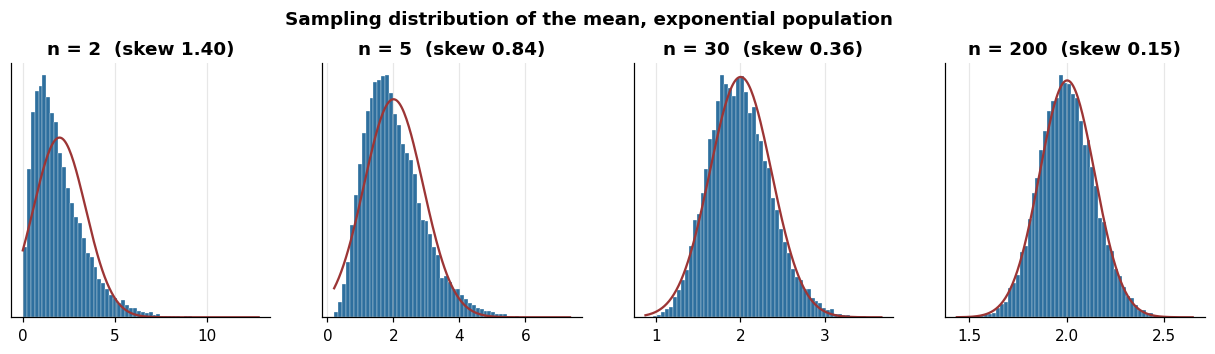

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for ax, n in zip(axes, (2, 5, 30, 200)):
    means = rng4.choice(pop, size=(20_000, n)).mean(axis=1)
    ax.hist(means, bins=60, density=True, color=BLUE,
            edgecolor="white", linewidth=0.2)
    xs = np.linspace(means.min(), means.max(), 200)
    ax.plot(xs, stats.norm.pdf(xs, pop.mean(), pop.std() / np.sqrt(n)),
            color=RED, lw=1.5)
    ax.set(title=f"n = {n}  (skew {float(stats.skew(means)):.2f})", yticks=[])
fig.suptitle("Sampling distribution of the mean, exponential population",
             y=1.04, fontweight="bold")
plt.show()

In [ ]:
# Where the CLT fails: the Cauchy distribution has no finite mean or variance,
# so no amount of averaging helps.
rng5 = np.random.default_rng(5)
cauchy_means = np.array([rng5.standard_cauchy(200).mean() for _ in range(2000)])
normal_means = np.array([rng5.normal(0, 1, 200).mean() for _ in range(2000)])
print(f"Cauchy, n=200 : sd of sample means = {cauchy_means.std():10.3f}")
print(f"Normal, n=200 : sd of sample means = {normal_means.std():10.3f}"
      f"   (theory {1/np.sqrt(200):.3f})")
print("\nThe CLT requires finite variance. Check its conditions before invoking it.")

### TASK 4.5

What is the standard error of the mean session length for a sample of
**n = 100** sessions? Use the population sd of `session_seconds` and the
$\sigma/\sqrt{n}$ formula.

In [ ]:
galat_baku = None

checks.task("4.5", galat_baku)

### 3.4 Is $n \ge 30$ actually enough? Measure it

Everything above is about shape. The question that matters is whether the
*interval you build* does what it promises. The population here is the 70,000
real session times — skewed, exactly like the data you will meet — and we know
its mean, so we can simply count how often a nominal 95% interval catches it.

In [ ]:
rng6 = np.random.default_rng(6)
mu_true = secs.mean()
R_COVER = 20_000
CHUNK = 2_000          # 20,000 x 1,000 at once would be 160 MB; this is 16 MB

rows = []
for n in (5, 10, 30, 100, 1_000):
    hits, widths = 0, 0.0
    t_crit = stats.t.ppf(0.975, n - 1)
    for start in range(0, R_COVER, CHUNK):
        k = min(CHUNK, R_COVER - start)
        S = rng6.choice(secs, size=(k, n))
        half = t_crit * S.std(ddof=1, axis=1) / np.sqrt(n)
        m = S.mean(axis=1)
        hits += int(((m - half <= mu_true) & (mu_true <= m + half)).sum())
        widths += float((2 * half).sum())
    c = hits / R_COVER
    rows.append({"n": n, "actual coverage": c, "nominal": 0.95,
                 # our own estimate needs an interval too
                 "+/- MC error": 1.96 * np.sqrt(c * (1 - c) / R_COVER),
                 "mean width (s)": widths / R_COVER})
cover = pd.DataFrame(rows)
print(cover.round(4).to_string(index=False))
print(f"\npopulation mean being chased: {mu_true:.2f} s")
print(f"({R_COVER:,} samples drawn at each n)")

**A nominal 95% interval delivers 93% at $n = 30$.** Not a catastrophe, but
not what it says on the label either: you would be wrong 7 times in 100 while
claiming 5. The shortfall comes from the skew, it closes monotonically as $n$
grows, and it is still not quite gone at $n = 1{,}000$.

This is why §3.3 said the rule of thumb is optimistic, and it is the honest
version of that claim — measured rather than asserted.

Note the `+/- MC error` column. Our coverage figures are themselves estimates
from a finite simulation, so they get intervals too. Without that column you
could not tell 0.9297 from 0.9437 — and the habit of asking "how precise is
this number?" about your *own* output is the one this chapter is really for.

### TASK 4.6

Report the **actual** coverage at $n = 30$ from the table above, as a
proportion.

In [ ]:
cakupan_n30 = None

checks.task("4.6", cakupan_n30)

## 4. Confidence intervals  (DEMO + TASK)

A 95% CI is a statement about the **procedure**: under repeated sampling, 95%
of such intervals contain the true parameter. It is *not* a 95% probability
that this particular interval does — this interval either contains it or does
not.

That sentence is abstract until you draw it, so draw it.

### 4.1 One hundred samples, one hundred intervals

In [ ]:
rng7 = np.random.default_rng(7)
K, n_s = 100, 200
S = rng7.choice(secs, size=(K, n_s))
m = S.mean(axis=1)
half = stats.t.ppf(0.975, n_s - 1) * S.std(ddof=1, axis=1) / np.sqrt(n_s)
lo, hi = m - half, m + half
hits = (lo <= mu_true) & (mu_true <= hi)

print(f"{K} samples of n = {n_s}, true mean {mu_true:.2f} s")
print(f"  intervals containing the truth : {hits.sum()}")
print(f"  intervals missing it           : {(~hits).sum()}   "
      f"(expected about {K * 0.05:.0f})")

fig, ax = plt.subplots(figsize=(9, 3.6))
ax.vlines(np.arange(K)[hits], lo[hits], hi[hits], color=BLUE, lw=1.2)
ax.vlines(np.arange(K)[~hits], lo[~hits], hi[~hits], color=RED, lw=2.0)
ax.plot(np.arange(K), m, ".", color=GREY, ms=2.5)
ax.axhline(mu_true, color="black", lw=1.2, ls="--")
ax.set(xlabel="sample number", ylabel="session_seconds",
       title=f"100 confidence intervals; {(~hits).sum()} miss the true mean "
             f"(dashed line)")
plt.show()

Every interval is a different guess, and a handful miss entirely. "95%
confidence" is a property of the *rule that drew these bars*, not of any one
bar. Nothing about the red intervals looks wrong from the inside — which is
precisely why you cannot say "there is a 95% chance the truth is in mine".

### TASK 4.7

Report how many of the 100 intervals **missed** the true mean.

In [ ]:
interval_meleset = None

checks.task("4.7", interval_meleset)

### 4.2 The textbook interval for a proportion is broken at small $n$

The Wald interval $\hat p \pm 1.96\sqrt{\hat p(1-\hat p)/n}$ is the one in
every introductory course. It is also badly miscalibrated for the rates we
care about — and conversion rates are small rates. The Wilson interval fixes
it at no extra cost.

In [ ]:
def wald_ci(k, n, z=1.96):
    p = k / n
    s = np.sqrt(p * (1 - p) / n)
    return p - z * s, p + z * s


def wilson_ci(k, n, z=1.96):
    p = k / n
    denom = 1 + z**2 / n
    centre = (p + z**2 / (2 * n)) / denom
    half = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / denom
    return centre - half, centre + half


rng8 = np.random.default_rng(8)
p_true = round(float(p_hat), 4)
rows = []
for n in (50, 100, 500, 2_000):
    k = rng8.binomial(n, p_true, 20_000)
    wl, wh = wald_ci(k, n)
    sl, sh = wilson_ci(k, n)
    rows.append({"n": n,
                 "Wald coverage": float(((wl <= p_true) & (p_true <= wh)).mean()),
                 "Wilson coverage": float(((sl <= p_true) & (p_true <= sh)).mean()),
                 "samples with 0 conversions": float((k == 0).mean())})
print(f"true rate p = {p_true}, nominal coverage 0.95\n")
print(pd.DataFrame(rows).round(4).to_string(index=False))

At $n = 50$ the Wald interval covers **90%** of the time, not 95. The reason
is in the last column: 9% of such samples contain *zero* conversions, and
Wald then returns the interval $[0, 0]$ — infinitely confident, and wrong.
Wilson never collapses, because it shrinks the centre towards ½.

Our A/B test has 35,000 per arm, so Wald is fine *here*. The lesson is that
you have to know why it is fine, and it stops being fine exactly when
somebody asks you to break the result down by segment.

### 4.3 When there is no formula: the bootstrap

A median, a correlation, a 90th percentile, a ratio of two medians — most
statistics have no tractable sampling distribution. Resample instead.

In [ ]:
secs_a = ab.loc[ab["variant"] == "A", "session_seconds"].to_numpy()


def bootstrap_dist(data, statistic, n_resamples=5_000, chunk=250, seed=9):
    """Bootstrap `statistic`, resampling in chunks.

    The obvious one-liner draws the whole n_resamples x len(data) matrix at
    once. Here that is 5,000 x 34,919 float64 = **1.4 GB**, and np.median
    then needs a sorted copy of it. Chunking keeps the peak at 70 MB for an
    identical answer. Watch for this whenever a resampling loop is written
    as a single array operation -- it is the usual way a notebook runs a
    laptop out of memory.
    """
    rng = np.random.default_rng(seed)
    n = len(data)
    out = np.empty(n_resamples)
    for start in range(0, n_resamples, chunk):
        k = min(chunk, n_resamples - start)
        out[start:start + k] = statistic(
            rng.choice(data, size=(k, n), replace=True), axis=1)
    return out


# 1. t-interval for the MEAN (valid, but answers a different question)
m_a, se_a = secs_a.mean(), stats.sem(secs_a)
lo_t, hi_t = stats.t.interval(0.95, len(secs_a) - 1, loc=m_a, scale=se_a)
print(f"mean   {m_a:7.2f}   t-interval    [{lo_t:7.2f}, {hi_t:7.2f}]")

# 2. Percentile bootstrap for the MEDIAN
boot = bootstrap_dist(secs_a, np.median, n_resamples=5_000)
blo, bhi = np.percentile(boot, [2.5, 97.5])
print(f"median {np.median(secs_a):7.2f}   bootstrap CI  [{blo:7.2f}, {bhi:7.2f}]")

# 3. BCa bootstrap, which corrects for bias and skew.
#    batch= caps how many resamples scipy holds at once, for the same reason.
res = stats.bootstrap((secs_a,), np.median, confidence_level=0.95,
                      n_resamples=5_000, method="BCa", batch=100,
                      random_state=0)
print(f"                    BCa interval  "
      f"[{res.confidence_interval.low:7.2f}, {res.confidence_interval.high:7.2f}]")

# 4. A statistic with no formula at all: the 90th percentile
p90 = stats.bootstrap((secs_a,), lambda x, axis: np.percentile(x, 90, axis=axis),
                      confidence_level=0.95, n_resamples=2_000,
                      method="percentile", batch=100, random_state=0)
print(f"\np90    {np.percentile(secs_a, 90):7.2f}   bootstrap CI  "
      f"[{p90.confidence_interval.low:7.2f}, {p90.confidence_interval.high:7.2f}]")

print("\nThe mean and the median are different quantities on skewed data.")
print("Choosing which to report is a substantive decision, not a technical one.")

The bootstrap asks the computer to do what the mathematician could not: it
treats the sample as a stand-in for the population and simply *repeats the
study* 5,000 times. Its one real requirement is that the sample be
representative — it can widen an interval to reflect uncertainty, but it
cannot repair a biased sample.

The percentile and BCa intervals agree to the decimal here. They diverge when
the bootstrap distribution is skewed or the statistic is biased, which happens
at small $n$ — with 35,000 observations there is nothing left for BCa to
correct. Prefer BCa anyway: it costs nothing and it is the one that still
works when the easy case does not hold.

## 5. Hypothesis testing  (DEMO + TASK)

### 5.1 The five steps

1. State $H_0$ and $H_1$ **before** looking.
2. Choose $\alpha$ — the false-positive rate you will tolerate.
3. Compute a test statistic.
4. Convert it to a $p$-value: *how surprising is this data if $H_0$ is true?*
5. Decide, then report the **effect size and its interval** — not the verdict.

### 5.2 What a $p$-value actually is

If the null is true, the $p$-value is **uniform on [0, 1]**. That single fact
disposes of most misinterpretations. Here are 20,000 tests between two groups
drawn from the *same* distribution, so the null is true by construction.

In [ ]:
rng10 = np.random.default_rng(10)
R, n_grp = 20_000, 60
X = rng10.normal(0, 1, (R, n_grp))
Y = rng10.normal(0, 1, (R, n_grp))
_, p_null = stats.ttest_ind(X, Y, axis=1)

print(f"{R:,} tests, null true in every one")
print(f"  P(p < 0.05) = {np.mean(p_null < 0.05):.4f}   <- this IS alpha")
print(f"  P(p < 0.01) = {np.mean(p_null < 0.01):.4f}")
print(f"  P(p < 0.50) = {np.mean(p_null < 0.50):.4f}")
print(f"  Kolmogorov-Smirnov test against Uniform(0,1): "
      f"p = {stats.kstest(p_null, 'uniform').pvalue:.3f}")

fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(p_null, bins=50, color=BLUE, edgecolor="white", lw=0.3)
ax.axhline(R / 50, color=RED, lw=1.5, ls="--", label="uniform expectation")
ax.set(xlabel="p-value", ylabel="count",
       title="Under a true null, every p-value is equally likely")
ax.legend(frameon=False, fontsize=8)
plt.show()

**Four things this rules out.**

| Claim | Why the histogram refutes it |
| --- | --- |
| "$p$ = 0.03 means a 3% chance the null is true" | The null is true in *all* 20,000 of these, and 3% of them still returned $p < 0.03$ |
| "A small $p$ means a big effect" | There is no effect at all here, yet 1,000 tests returned $p < 0.05$ |
| "$p$ = 0.51 means the groups are the same" | $p$ = 0.51 is exactly as likely as $p$ = 0.02 when nothing is going on |
| "$p$ > 0.05 proves no effect" | A flat distribution carries no information about size |

A $p$-value answers one question only: *if the null were true, how often would
I see data at least this extreme?*

### 5.3 Two errors, and the power to avoid the second

In [ ]:
print(f"{'':<26}{'H0 true':>16}{'H0 false':>16}")
print("-" * 58)
print(f"{'reject H0':<26}{'Type I (alpha)':>16}{'correct (power)':>16}")
print(f"{'fail to reject H0':<26}{'correct':>16}{'Type II (beta)':>16}")

print("\nThe costs are never symmetric, and they are yours to weigh:")
print("  ship a useless redesign  (Type I) -> wasted engineering, lost goodwill")
print("  miss a real improvement  (Type II) -> revenue never earned, silently")

In [ ]:
def power_two_prop(p1, rel_lift, n_each, alpha=0.05):
    """Power of a two-proportion z-test, via the arcsine effect size h.

    Two arms of n_each give var(h_hat) = 2/n_each, so the test statistic is
    h * sqrt(n_each / 2). Section 7 inverts this to get a sample size.
    """
    p2 = p1 * (1 + rel_lift)
    h = abs(2 * np.arcsin(np.sqrt(p2)) - 2 * np.arcsin(np.sqrt(p1)))
    z_a = stats.norm.ppf(1 - alpha / 2)
    return float(stats.norm.cdf(h * np.sqrt(n_each / 2) - z_a)
                 + stats.norm.cdf(-h * np.sqrt(n_each / 2) - z_a))


rate_a = ab.loc[ab["variant"] == "A", "converted"].mean()
n_arm = int(ab["variant"].value_counts().min())

print(f"baseline rate {rate_a:.4%}, n = {n_arm:,} per arm\n")
print(f"{'true relative lift':>20}{'power':>10}")
for rel in (0.02, 0.05, 0.08, 0.12, 0.20, 0.30):
    print(f"{rel:>19.0%}{power_two_prop(rate_a, rel, n_arm):>10.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.4))
rels = np.linspace(0.001, 0.35, 300)
for n, style in [(10_000, ":"), (n_arm, "-"), (100_000, "--")]:
    axes[0].plot(rels, [power_two_prop(rate_a, r, n) for r in rels], style,
                 color=BLUE, lw=1.8, label=f"n = {n:,} per arm")
axes[0].axhline(0.80, color=RED, lw=1.1, ls="--")
axes[0].annotate("conventional 80%", (0.005, 0.83), color=RED, fontsize=8)
axes[0].set(xlabel="true relative lift", ylabel="power",
            title="Power against the effect you are hunting", ylim=(0, 1.02))
axes[0].legend(frameon=False, fontsize=8, loc="lower right")

# the two error rates as areas
xs = np.linspace(-4, 7, 500)
crit = stats.norm.ppf(0.975)
axes[1].plot(xs, stats.norm.pdf(xs, 0, 1), color=GREY, lw=1.6)
axes[1].plot(xs, stats.norm.pdf(xs, 3, 1), color=BLUE, lw=1.6)
axes[1].fill_between(xs, 0, stats.norm.pdf(xs, 0, 1), where=xs >= crit,
                     color=RED, alpha=0.55, label="Type I (alpha)")
axes[1].fill_between(xs, 0, stats.norm.pdf(xs, 3, 1), where=xs < crit,
                     color=GOLD, alpha=0.55, label="Type II (beta)")
axes[1].axvline(crit, color="black", lw=1.0, ls="--")
axes[1].set(title="Move the threshold and you trade one error for the other",
            xlabel="test statistic", yticks=[])
axes[1].legend(frameon=False, fontsize=8)
plt.show()

Two things to take from the left panel. First, power is a statement about an
effect size you have to *name* — "is this test well powered?" is not a
question until you say powered for what. Second, the curve is steep: at
35,000 per arm this experiment sees a 12% lift almost always and a 5% lift
less than a third of the time.

The right panel is the trade-off. Lowering $\alpha$ slides the dashed line
right, shrinking the red area and growing the gold one. You cannot shrink both
without more data.

### TASK 4.8

What is the power of this experiment to detect an **8% relative lift**?

In [ ]:
daya_uji = None

checks.task("4.8", daya_uji)

### 5.4 A complete two-group comparison

The full reporting discipline: assumptions, test, **effect size**, confidence
interval, power. A $p$-value on its own is a far weaker statement.

In [ ]:
a = ab.loc[ab["variant"] == "A", "session_seconds"].to_numpy()
b = ab.loc[ab["variant"] == "B", "session_seconds"].to_numpy()
rng11 = np.random.default_rng(11)

# 1. Assumptions (on a subsample -- Shapiro-Wilk is not meaningful at n=35,000)
sub_a = rng11.choice(a, 500, replace=False)
sub_b = rng11.choice(b, 500, replace=False)
print(f"Shapiro A p = {stats.shapiro(sub_a).pvalue:.4f}  "
      f"| Shapiro B p = {stats.shapiro(sub_b).pvalue:.4f}")
print(f"Levene    p = {stats.levene(a, b).pvalue:.4f}")
print("(Session times are log-normal, so normality is rejected. At this n the")
print(" CLT makes the t-test robust anyway -- but check, do not assume.)\n")

# 2. Test: Welch by default. Note the sign -- ttest_ind(a, b) tests a - b.
t_stat, p_t = stats.ttest_ind(a, b, equal_var=False)
print(f"Welch t = {t_stat:.3f}, p = {p_t:.3e}")

# 3. Effect size (Cohen's d, pooled sd)
n1, n2 = len(a), len(b)
sp = np.sqrt(((n1 - 1) * a.var(ddof=1) + (n2 - 1) * b.var(ddof=1)) / (n1 + n2 - 2))
d = (b.mean() - a.mean()) / sp
print(f"difference = {b.mean() - a.mean():.2f} s, Cohen's d = {d:.3f}")

# 4. CI for the difference (Welch-Satterthwaite df)
se_d = np.sqrt(a.var(ddof=1) / n1 + b.var(ddof=1) / n2)
df_w = se_d**4 / ((a.var(ddof=1)/n1)**2/(n1-1) + (b.var(ddof=1)/n2)**2/(n2-1))
clo, chi = stats.t.interval(0.95, df_w, loc=b.mean() - a.mean(), scale=se_d)
print(f"95% CI for the difference: [{clo:.2f}, {chi:.2f}] s")

# 5. Achieved power (statsmodels-free, via the non-central t)
ncp = d * np.sqrt(n1 * n2 / (n1 + n2))
crit_t = stats.t.ppf(0.975, n1 + n2 - 2)
power = (1 - stats.nct.cdf(crit_t, n1 + n2 - 2, ncp)
         + stats.nct.cdf(-crit_t, n1 + n2 - 2, ncp))
print(f"achieved power = {power:.3f}")

The sentence to write:

> *Sessions on variant B lasted 3.5 s longer on average (95% CI 2.4 to 4.7 s;
> Welch t = 6.15, p < 0.001; Cohen's d = 0.046).*

The negative sign on t merely reflects that `ttest_ind(a, b)` tests $a - b$;
read the direction from the group means, not from the sign of the statistic.

Note that Cohen's d is **0.046** — a trivially small effect that is
overwhelmingly significant, because $n = 70{,}000$. **Statistical significance
is not practical significance.** Always report the effect size.

### TASK 4.9

Report Cohen's $d$ for the difference in `session_seconds` between the arms.

In [ ]:
cohens_d = None

checks.task("4.9", cohens_d)

### 5.5 Choosing the right test, and what "not significant" means

In [ ]:
print(f"{'question':<42}{'test':<26}{'here'}")
print("-" * 86)
print(f"{'two means, unequal variances?':<42}{'Welch t-test':<26}"
      f"p = {stats.ttest_ind(a, b, equal_var=False).pvalue:.2e}")
print(f"{'two proportions?':<42}{'two-proportion z-test':<26}see section 7")
print(f"{'two categorical variables associated?':<42}{'chi-square':<26}"
      f"p = {stats.chi2_contingency(pd.crosstab(ab['variant'], ab['converted']))[1]:.2e}")
print(f"{'three or more means?':<42}{'one-way ANOVA':<26}"
      f"p = {stats.f_oneway(*[g['session_seconds'].to_numpy() for _, g in ab.groupby('day')]).pvalue:.3f}")
print(f"{'non-normal, small n?':<42}{'Mann-Whitney U':<26}"
      f"p = {stats.mannwhitneyu(a, b).pvalue:.2e}")

f_day, p_day_anova = stats.f_oneway(
    *[g["session_seconds"].to_numpy() for _, g in ab.groupby("day")])
by_day = ab.groupby("day")["session_seconds"]
day_mean, day_sd, day_n = by_day.mean(), by_day.std(ddof=1), by_day.count()
hi_day, lo_day = day_mean.idxmax(), day_mean.idxmin()
gap = day_mean[hi_day] - day_mean[lo_day]
se_gap = np.sqrt(day_sd[hi_day]**2 / day_n[hi_day]
                 + day_sd[lo_day]**2 / day_n[lo_day])

print(f"\nANOVA across the 14 days: F = {f_day:.3f}, p = {p_day_anova:.4f}"
      f"  -> not significant")
print(f"  daily means run from {day_mean.min():.1f} s to {day_mean.max():.1f} s")

n_pairs = 14 * 13 // 2
z_naive = stats.norm.ppf(0.975)
z_bonf = stats.norm.ppf(1 - 0.05 / (2 * n_pairs))
print(f"\nBut look at the widest gap, day {hi_day} vs day {lo_day} = {gap:.2f} s:")
print(f"  naive 95% CI          [{gap - z_naive*se_gap:+.2f}, "
      f"{gap + z_naive*se_gap:+.2f}]  excludes zero -- 'significant'!")
print(f"  corrected for the {n_pairs} pairs you implicitly searched:")
print(f"                        [{gap - z_bonf*se_gap:+.2f}, "
      f"{gap + z_bonf*se_gap:+.2f}]  includes zero")
print(f"\nThe naive interval is invalid because days {hi_day} and {lo_day} were")
print(f"chosen *after* seeing the means. Correcting for the search reconciles it")
print(f"with the ANOVA. Section 6 is about doing this deliberately.")

**Absence of evidence is not evidence of absence.** The ANOVA is
non-significant, and the correct reading is that any day-to-day differences
are small relative to this experiment's resolution — not that they are zero.
To claim "no effect" you need an equivalence test or a confidence interval
tight around zero, and we have neither.

**And notice the trap the ANOVA just saved you from.** Scanning 14 daily means
and reporting the widest gap looks like one comparison. It is 91. The naive
interval on that gap excludes zero and would have been written up as a
finding; once the search is accounted for, it does not. This is why an
omnibus test comes before pairwise ones, and it is the whole subject of §6.

Note also that the Mann–Whitney U test agrees with Welch here. When a
parametric and a non-parametric test disagree, that disagreement is
information about your assumptions — investigate it rather than picking the
answer you prefer.

## 6. Multiple testing  (DEMO + TASK)

The experiment finishes. Somebody asks: *"but does it work on mobile? in week
two? for engaged users?"* Every slice is a legitimate question on its own. The
problem is their **number**.

In [ ]:
for m in (1, 5, 10, 20, 50, 90):
    print(f"m = {m:>3} independent tests:  "
          f"P(at least one false positive) = {1 - 0.95**m:.3f}")

### 6.1 Ten real slices of our own experiment

Rather than take those p-values on faith, compute them. Ten segments anybody
would plausibly ask for, each tested with the same two-proportion z-test.

In [ ]:
median_pages = ab["pages_viewed"].median()
ab["half"] = np.where(ab["day"] <= 7, "week1", "week2")
ab["engagement"] = np.where(ab["pages_viewed"] > median_pages, "many", "few")

SEGMENTS = {}
for dev in ("mobile", "desktop"):
    SEGMENTS[f"device = {dev}"] = ab["device"].eq(dev).to_numpy()
for wk in ("week1", "week2"):
    SEGMENTS[f"half = {wk}"] = ab["half"].eq(wk).to_numpy()
for eng in ("few", "many"):
    SEGMENTS[f"pages = {eng}"] = ab["engagement"].eq(eng).to_numpy()
for dev in ("mobile", "desktop"):
    for wk in ("week1", "week2"):
        SEGMENTS[f"{dev}, {wk}"] = (ab["device"].eq(dev)
                                    & ab["half"].eq(wk)).to_numpy()

CONVERTED = ab["converted"].to_numpy()
IS_B = (ab["variant"].to_numpy() == "B")


def z_test_segment(mask, is_b):
    """Two-proportion z-test inside one segment. Returns (lift, z, p)."""
    c, b_flag = CONVERTED[mask], is_b[mask]
    n_b, n_a = b_flag.sum(), (~b_flag).sum()
    x_b, x_a = c[b_flag].sum(), c[~b_flag].sum()
    r_a, r_b = x_a / n_a, x_b / n_b
    pool = (x_a + x_b) / (n_a + n_b)
    se = np.sqrt(pool * (1 - pool) * (1 / n_a + 1 / n_b))
    z = (r_b - r_a) / se
    return r_b - r_a, z, 2 * (1 - stats.norm.cdf(abs(z)))


seg_rows = []
for name, mask in SEGMENTS.items():
    lift, z, p = z_test_segment(mask, IS_B)
    seg_rows.append({"segment": name, "n": int(mask.sum()),
                     "lift_pp": lift * 100, "z": z, "p": p})
seg = pd.DataFrame(seg_rows)
print(seg.round({"lift_pp": 3, "z": 3, "p": 5}).to_string(index=False))
print(f"\nraw p < 0.05: {(seg['p'] < 0.05).sum()} of {len(seg)} segments")

Seven "wins" out of ten. Reported as they stand, that reads like seven
findings. Before believing any of them, find out how many such wins pure noise
would produce.

### 6.2 A placebo experiment

Shuffle the `variant` label. The shuffled label is attached to nobody's real
experience, so **every** segment now has a true null — any "win" is definitely
false. Repeat 300 times and count.

In [ ]:
def adjust(pvals, method):
    """Bonferroni / Holm / Benjamini-Hochberg, without statsmodels."""
    p = np.asarray(pvals, dtype=float)
    m = len(p)
    if method == "bonferroni":
        return np.minimum(p * m, 1.0)
    if method == "holm":
        order = np.argsort(p)
        adj = np.empty(m)
        run = 0.0
        for i, idx in enumerate(order):
            run = max(run, (m - i) * p[idx])
            adj[idx] = min(run, 1.0)
        return adj
    if method == "fdr_bh":
        order = np.argsort(p)[::-1]
        adj = np.empty(m)
        run = 1.0
        for i, idx in enumerate(order):
            rank = m - i
            run = min(run, p[idx] * m / rank)
            adj[idx] = run
        return adj
    raise ValueError(method)


rng12 = np.random.default_rng(0)
R_PLACEBO = 300
counts = {"raw": [], "bonferroni": [], "holm": [], "fdr_bh": []}
for _ in range(R_PLACEBO):
    shuffled = rng12.permutation(IS_B)
    ps = np.array([z_test_segment(m_, shuffled)[2] for m_ in SEGMENTS.values()])
    counts["raw"].append((ps < 0.05).sum())
    for meth in ("bonferroni", "holm", "fdr_bh"):
        counts[meth].append((adjust(ps, meth) < 0.05).sum())

print(f"{R_PLACEBO} placebo experiments x {len(SEGMENTS)} segments, "
      f"null true everywhere\n")
print(f"{'method':<14}{'mean # wins':>13}{'P(>= 1 win)':>14}{'worst run':>12}")
print("-" * 53)
for meth, label in [("raw", "uncorrected"), ("bonferroni", "Bonferroni"),
                    ("holm", "Holm"), ("fdr_bh", "Benjamini-H")]:
    v = np.array(counts[meth])
    print(f"{label:<14}{v.mean():>13.2f}{np.mean(v >= 1):>14.3f}{v.max():>12}")

**Uncorrected, 28% of placebo experiments produce at least one "significant"
segment — from a label that means nothing.** After correction that falls to
about 6%, which is what a 5% error rate is supposed to look like.

Two details worth noticing. The 28% is lower than the $1 - 0.95^{10} = 40\%$
on the slide, because these segments *overlap* — "mobile" and "mobile, week1"
share sessions, so the ten tests are positively dependent rather than
independent. And correction is not merely conservative: it is **calibrated**.
It buys back the error rate you were promised.

### 6.3 Correcting the real segments

In [ ]:
seg_adj = seg.copy()
for meth in ("bonferroni", "holm", "fdr_bh"):
    seg_adj[meth] = adjust(seg["p"].to_numpy(), meth)

print(seg_adj[["segment", "p", "bonferroni", "holm", "fdr_bh"]]
      .round(5).to_string(index=False))

print(f"\n{'method':<26}{'what it controls':<44}{'survives'}")
print("-" * 82)
print(f"{'none':<26}{'nothing; not defensible':<44}{(seg['p'] < 0.05).sum()}")
print(f"{'Bonferroni':<26}{'chance of ANY false claim (FWER)':<44}"
      f"{(seg_adj['bonferroni'] < 0.05).sum()}")
print(f"{'Holm':<26}{'the same FWER, with more power':<44}"
      f"{(seg_adj['holm'] < 0.05).sum()}")
print(f"{'Benjamini-Hochberg':<26}{'expected FRACTION of claims that are false':<44}"
      f"{(seg_adj['fdr_bh'] < 0.05).sum()}")

print("\nsurvivors under Holm:")
for s in seg_adj.loc[seg_adj["holm"] < 0.05, "segment"]:
    print("   ", s)

Holm dominates Bonferroni everywhere — it can only ever reject more — so plain
Bonferroni is never the better choice. FWER methods ask *"what is the chance I
make any false claim?"* and suit confirmatory work; FDR asks *"what fraction
of my claims will be false?"* and suits screening a long list of candidates
you intend to follow up.

Neither is wrong. What is **not** defensible is reporting all seven as
discoveries without saying that ten tests were run.

### TASK 4.10

How many of the ten segments survive the **Benjamini–Hochberg** correction at
0.05?

In [ ]:
lolos_bh = None

checks.task("4.10", lolos_bh)

## 7. Analysing the A/B test  (DEMO + TASK)

### Step 0 — checks *before* the primary metric

A sample-ratio mismatch means randomisation or logging is broken, and no
result from the test can be trusted. Check it every time, and stop if it
fails: no p-value rescues a broken experiment.

In [ ]:
counts_arm = ab["variant"].value_counts().sort_index()
chi2_srm, p_srm = stats.chisquare(counts_arm.to_numpy())
print("Sample ratio check")
print(counts_arm.to_string())
print(f"  observed split: {counts_arm.iloc[1] / counts_arm.sum():.4f}")
print(f"  chi2 p = {p_srm:.3f}  -> "
      f"{'OK' if p_srm > 0.01 else 'BROKEN, stop here'}\n")

print("Balance on a pre-treatment covariate (device):")
dev = pd.crosstab(ab["variant"], ab["device"], normalize="index")
print(dev.round(4).to_string())
print(f"  chi2 p = "
      f"{stats.chi2_contingency(pd.crosstab(ab['variant'], ab['device']))[1]:.3f}")
print("\nDevice is balanced across arms, so it cannot confound the comparison.")
print("A variable that is not a confounder cannot reverse anything -- whatever")
print("section 6 found on mobile is heterogeneity, not Simpson's paradox.")

### Step 1 — the primary metric

In [ ]:
grp = ab.groupby("variant")["converted"].agg(["sum", "count", "mean"])
print(grp.round(5).to_string())

conv_counts = grp["sum"].to_numpy()
trials = grp["count"].to_numpy()
r1, r2 = conv_counts / trials
pool = conv_counts.sum() / trials.sum()

se_pool = np.sqrt(pool * (1 - pool) * (1 / trials[0] + 1 / trials[1]))
z = (r2 - r1) / se_pool
p_two = 2 * (1 - stats.norm.cdf(abs(z)))

se_unpooled = np.sqrt(r1 * (1 - r1) / trials[0] + r2 * (1 - r2) / trials[1])
diff = r2 - r1

print(f"\ncontrol {r1:.4%}   variant {r2:.4%}")
print(f"absolute lift {diff:+.4%}  "
      f"(95% CI [{diff - 1.96*se_unpooled:+.4%}, {diff + 1.96*se_unpooled:+.4%}])")
print(f"relative lift {diff / r1:+.2%}")
print(f"z = {z:.3f}, p = {p_two:.6f}")

### Step 2 — was the test big enough?

The sample size should have been computed **before** the experiment, from the
minimum detectable effect. Here is that calculation, after the fact:

In [ ]:
def n_per_arm(p1, rel_mde, alpha=0.05, power_target=0.80):
    """Sample size *per arm* to detect a relative lift, via Cohen's h.

    Two independent arms of n each give var(h_hat) = 2/n, hence the factor of
    2. Drop it and you will under-order your sample by half -- the single most
    common arithmetic slip in experiment design.
    """
    p2 = p1 * (1 + rel_mde)
    h = abs(2 * np.arcsin(np.sqrt(p2)) - 2 * np.arcsin(np.sqrt(p1)))
    z_a = stats.norm.ppf(1 - alpha / 2)
    z_b = stats.norm.ppf(power_target)
    return int(np.ceil(2 * ((z_a + z_b) / h) ** 2))


print(f"{'MDE':>6}{'n per arm':>12}{'we have':>10}{'verdict':>22}"
      f"{'power at our n':>16}")
print("-" * 66)
for mde in (0.05, 0.10, 0.12, 0.20):
    n_req = n_per_arm(r1, mde)
    verdict = "adequately powered" if trials[0] >= n_req else "UNDERPOWERED"
    print(f"{mde:>6.0%}{n_req:>12,}{trials[0]:>10,}{verdict:>22}"
          f"{power_two_prop(r1, mde, trials[0]):>16.3f}")

print("\nHalving the effect you want to detect quadruples the sample required:")
print("the denominator is h^2, and h is roughly proportional to (p2 - p1).")
print("\nSanity check -- the two formulas must agree:")
n_80 = n_per_arm(r1, 0.12)
print(f"  n_per_arm says {n_80:,} per arm gives 80% power at a 12% lift")
print(f"  power_two_prop at that n: {power_two_prop(r1, 0.12, n_80):.3f}")

### Step 3 — what "80% power" feels like from the inside

A test powered at 80% **fails to detect a real effect one time in five**. That
is not a defect; it is the number you agreed to. Simulate the 80%-powered
design 2,000 times at its +12% lift and look at the spread of outcomes.

In [ ]:
rng13 = np.random.default_rng(13)
REPS = 2_000
n_sim = n_per_arm(float(r1), 0.12)   # exactly the 80%-powered design
p_ctrl = float(r1)
p_treat = p_ctrl * 1.12

x_a = rng13.binomial(n_sim, p_ctrl, REPS)
x_b = rng13.binomial(n_sim, p_treat, REPS)
ra, rb = x_a / n_sim, x_b / n_sim
pooled = (x_a + x_b) / (2 * n_sim)
se_sim = np.sqrt(pooled * (1 - pooled) * 2 / n_sim)
z_sim = (rb - ra) / se_sim
p_sim = 2 * (1 - stats.norm.cdf(np.abs(z_sim)))

print(f"{REPS:,} repeats of a {n_sim:,}-per-arm test, true lift +12%")
print(f"  design power        {power_two_prop(p_ctrl, 0.12, n_sim):.3f}")
print(f"  P(p < 0.05)         {np.mean(p_sim < 0.05):.3f}   <- matches")
print(f"  P(0.05 < p < 0.10)  {np.mean((p_sim >= 0.05) & (p_sim < 0.10)):.3f}"
      f"   <- 'so close', and still a correct non-result")
print(f"  P(p > 0.10)         {np.mean(p_sim >= 0.10):.3f}")
rel_measured = (rb - ra) / ra
print(f"\n  measured relative lift, 5th to 95th percentile: "
      f"{np.percentile(rel_measured, 5):+.1%} to "
      f"{np.percentile(rel_measured, 95):+.1%}")
print("  (the truth is +12.0% in every one of these runs)")

won = p_sim < 0.05
print(f"\nThe winner's curse:")
print(f"  mean lift over all {REPS:,} runs        {rel_measured.mean():+.2%}")
print(f"  mean lift over the {won.sum():,} that 'won'  "
      f"{rel_measured[won].mean():+.2%}   <- overstated by "
      f"{rel_measured[won].mean() - rel_measured.mean():.2%}")

**Even when the effect is exactly real, one run in five misses it, and the
measured lift lands anywhere between +4.7% and +19.6%.** The truth is +12.0%
in every single run; all of that spread is sampling noise.

Two consequences you will meet in practice. A non-significant test is weak
evidence of no effect — it happens 20% of the time to a real, correctly
powered effect. And the lift a *winning* test reports is biased **upward**,
because the runs that cleared 0.05 are disproportionately the ones that
landed high. Ask for the interval, not the point estimate.

### TASK 4.11

Report the two-sided p-value for the difference in conversion rate.

In [ ]:
p_konversi = None

checks.task("4.11", p_konversi)

### TASK 4.12

Report the **absolute** lift (as a proportion, e.g. 0.0072 for 0.72 points).

In [ ]:
lift_absolut = None

checks.task("4.12", lift_absolut)

## 8. The cost of peeking  (DEMO + TASK)

Checking the p-value repeatedly and stopping when it crosses 0.05 inflates the
false-positive rate dramatically. Here we simulate it on data where the null
is **true by construction**, so every "significant" result is a false positive.

In [ ]:
def peeking_experiment(n_max=2000, step=50, n_sims=400, seed=0):
    """Return (rate with peeking, rate testing once at the end)."""
    rng = np.random.default_rng(seed)
    peeked = fixed = 0
    checkpoints = range(step, n_max + 1, step)
    for _ in range(n_sims):
        x = rng.normal(0, 1, n_max)
        y = rng.normal(0, 1, n_max)          # SAME distribution: null is true
        hit = False
        for k in checkpoints:
            if stats.ttest_ind(x[:k], y[:k]).pvalue < 0.05:
                hit = True
                break
        peeked += hit
        fixed += stats.ttest_ind(x, y).pvalue < 0.05
    return peeked / n_sims, fixed / n_sims


rate_peek, rate_fixed = peeking_experiment()
print(f"stopping at the first significant look : {rate_peek:.1%}")
print(f"testing once, at the planned end       : {rate_fixed:.1%}")
print(f"nominal alpha                          : 5.0%")
print("\nThe null is true in every simulation. Peeking manufactures")
print("false positives out of nothing.")

The fix is not "never look". It is to decide the stopping rule **in advance** —
a fixed sample size, or a sequential design (alpha spending, group sequential
boundaries) that budgets the error rate across the looks you intend to take.

### TASK 4.13

Report the false-positive rate under peeking (as a proportion).

In [ ]:
laju_peeking = None

checks.task("4.13", laju_peeking)

## 9. Summary

1. **Probability runs in two directions and they are not the same.**
   $P(A \mid B) \ne P(B \mid A)$; 58% of conversions were mobile while only
   4% of mobile sessions converted.
2. **At a low base rate, precision is governed by the false-positive rate.**
   Perfect sensitivity bought 1.3 points; cutting the FPR bought 57.
3. **A distribution is a claim about a process**, and the claim is testable —
   `pages_viewed` has variance/mean = 0.99, `session_seconds` has 44.5.
4. **SD describes the population; SE describes your estimate.** Only the
   second shrinks with $n$, and only as $1/\sqrt{n}$.
5. **$n \ge 30$ is a rule of thumb, not a guarantee.** On these skewed data a
   nominal 95% interval delivered 93% at $n = 30$.
6. **Under a true null the $p$-value is uniform.** That single fact kills
   every common misreading of it.
7. **Significance is not importance.** Cohen's $d$ = 0.046 with
   $p < 10^{-9}$. Report the effect size and its interval, always.
8. **Ten questions are not one question.** Uncorrected, 28% of placebo
   experiments produced a "win" from a meaningless label.

### Back to §0

You listed what you needed before answering "4.4% versus 4.7% — ship it?".
The full answer needs: the **sample size** (35,000 per arm), a **sample-ratio
check** (p = 0.54, passes), the **absolute lift with an interval** (+0.72 pp,
95% CI +0.41 to +1.03), the **relative lift** (+16.6%), whether the test was
**powered** for the effect worth shipping, whether the analysis was **decided
in advance** rather than peeked at, and how many **segments** were examined.
Compare that list with yours.

## 10. Take-home  (assessed)

**A. A Poisson call centre.** A centre receives on average 8 calls per hour.
Compute (a) $P(X = 0)$ in an hour; (b) $P(X \ge 12)$; (c) the probability the
wait to the next call exceeds 15 minutes. State which distribution you used
for (c) and why it is not the Poisson. Then (d): the centre's manager reports
that the *variance* of hourly call counts last month was 31. What does that
tell you about the Poisson assumption, and what would you do about it?

**B. Interpret a confidence interval.** A 95% CI for a mean difference is
$[-0.4, 6.8]$. Which of these are correct, and correct those that are not?
(a) *"There is a 95% probability the true difference is between −0.4 and 6.8."*
(b) *"We cannot reject $H_0$ at $\alpha = 0.05$."*
(c) *"The effect is probably zero."*
(d) *"A larger sample would produce a narrower interval."*

**C. Design an A/B test.** A checkout redesign will ship only for a relative
lift of at least 8% on a 2.8% baseline. Compute the required sample size per
arm at 80% power, state the expected duration at 12,000 sessions/day, and list
**three checks** you would run before analysing the primary metric.

**D. Segment analysis, done honestly.** Split the A/B result by `device`.
Report the lift in each segment with a confidence interval, apply an
appropriate multiplicity correction, and answer: *does variant B work better on
mobile than on desktop, or is the difference within noise?* Be explicit about
how many tests you performed in total — including the ten in §6.

**E. What is missing.** An analyst reports: *"The variant increased revenue per
user by 3.2% (p = 0.03), so we should ship it."* Identify **four** pieces of
information missing from that statement and say what each would tell you.

---
**Next week:** turning raw columns into features a model can actually learn from.